## Section 3 Data Analysis
now we start analyzing and explain why churn rate is high for certain groups?

tenure_groups
1-3 Months     12.10
4-12 Months    17.16
1-2 Years      14.89
2-3 Years      23.09
4-8 Years      32.75
Name: count, dtype: float64

=== CHURN RATE BY COHORT ===
tenure_groups
1-3 Months     59.11
4-12 Months    41.09
1-2 Years      29.51
2-3 Years      20.87
4-8 Years       9.64
Name: churn_numeric, dtype: float64


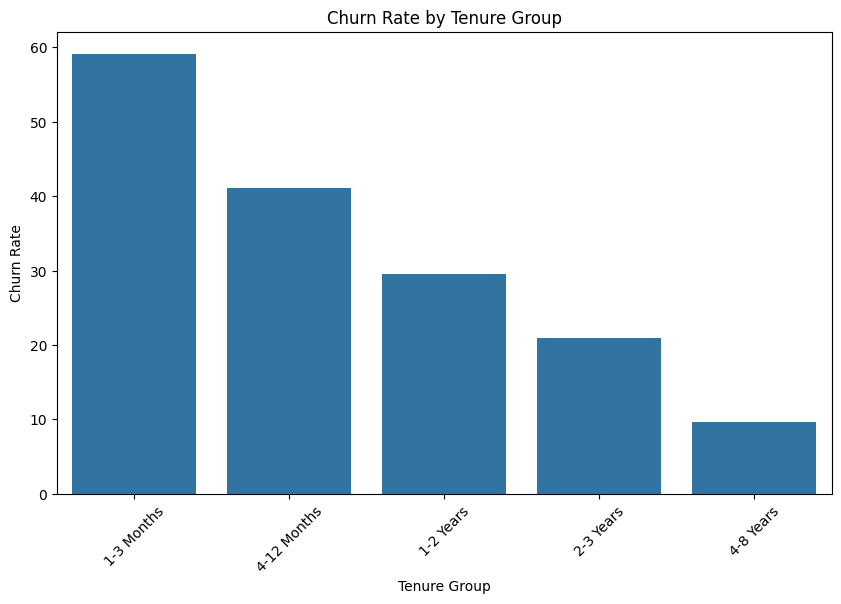

In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load the data
df = pd.read_csv('../data/telco_churn_clean.csv')
conn = sqlite3.connect('../telco_churn.db')

# 2. Convert Churn to a binary number (1 or 0) for easy math
# Note: .apply(lambda) used for readability
# Production alternative: df['churn_numeric'] = (df['churn'] == 'Yes').astype(int)
df['churn_numeric'] = df['churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# 3. Define the Business Time-Buckets (Cohorts)
# The PM cares about the first 3 months, then we group the rest logically
months = [0,3,12,24,48,96]
labels = ['1-3 Months', '4-12 Months', '1-2 Years', '2-3 Years', '4-8 Years' ]
df['tenure_groups'] = pd.cut(df['tenure'], bins=months, labels=labels, right=False)
# this is giving me the amount of people in each tenure group, I think a percetange would be better
print(round((df['tenure_groups'].value_counts() / len(df)) * 100, 2).sort_index())

# 4. Calculate the average churn rate (%) for each cohort
print(f"\n=== CHURN RATE BY COHORT ===")
churn_rate_by_tenure = round(df.groupby('tenure_groups')['churn_numeric'].mean()*100, 2)
print(churn_rate_by_tenure)

# 5. Visualize the churn rate by tenure group
# I want to visualize this data, so I can see if there are any patterns
plt.figure(figsize=(10,6))
sns.barplot(x=churn_rate_by_tenure.index, y=churn_rate_by_tenure.values)
plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate')
plt.xticks(rotation=45)
plt.show()  

## Finding 1: Activation Problem
59\% of customers churn within their first 3 months.
The product is failing to deliver value during the critical activation window.

## Hypothesis
Customers without tech support and on month-to-month contracts 
are the primary drivers of early churn.

## Next: Test hypothesis with SQL segmentation

In [3]:
# Query 1: Churn rate by contract type
query1 = pd.read_sql("""
    SELECT contract,
    COUNT(*) as customers,
    (CASE WHEN tenure >= 0 AND tenure < 3 THEN '1-3 Months'
        WHEN tenure >= 3 AND tenure < 12 THEN '4-12 Months'
        WHEN tenure >= 12 AND tenure < 24 THEN '1-2 Years'
        WHEN tenure >= 24 AND tenure < 48 THEN '2-3 Years'
        WHEN tenure >= 48 AND tenure < 96 THEN '4-8 Years'
        ELSE '8+ Years' END) as tenure_group,
    ROUND(SUM(CASE WHEN churn = 'Yes' THEN 1 ELSE 0 END)*100.0 / COUNT(*), 2) as churn_rate
    FROM customers
    GROUP BY contract, tenure_group
    ORDER BY churn_rate DESC
    """, conn)
print("=== CHURN RATE BY CONTRACT TYPE ===")
print(query1)

=== CHURN RATE BY CONTRACT TYPE ===
          contract  customers tenure_group  churn_rate
0   Month-to-month        834   1-3 Months       60.07
1   Month-to-month       1074  4-12 Months       45.62
2   Month-to-month        765    1-2 Years       37.65
3   Month-to-month        845    2-3 Years       33.61
4   Month-to-month        357    4-8 Years       25.77
5         One year         14   1-3 Months       14.29
6         One year        662    4-8 Years       13.14
7         One year        199    1-2 Years       10.55
8         One year        510    2-3 Years        9.80
9         One year         87  4-12 Months        6.90
10        Two year       1284    4-8 Years        3.35
11        Two year        269    2-3 Years        1.86
12        Two year         83    1-2 Years        0.00
13        Two year          3   1-3 Months        0.00
14        Two year         46  4-12 Months        0.00


The observation is that month-to-month customers have the highest churn rate, especially in the 1-3 months tenure group. 
This suggests that customers on month-to-month contracts are more likely to churn early in their tenure
compared to those on longer-term contracts.

=====CENTRAL QUESTIONS=====
"For each contract type, what % of customers adopted Feature X?"

In [4]:
print(df['onlinesecurity'].unique())
print(df['deviceprotection'].unique())

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str


In [5]:
query2 = pd.read_sql("""
    SELECT COUNT(*) as users,
    (CASE WHEN tenure >= 0 AND tenure < 3 THEN '1-3 Months'
        WHEN tenure >= 3 AND tenure < 12 THEN '4-12 Months'
        WHEN tenure >= 12 AND tenure < 24 THEN '1-2 Years'
        WHEN tenure >= 24 AND tenure < 48 THEN '2-3 Years'
        WHEN tenure >= 48 AND tenure < 96 THEN '4-8 Years'
        ELSE '8+ Years' END) as tenure_group,
    ROUND(SUM(CASE WHEN churn = 'Yes' THEN 1 ELSE 0 END)*100.0 / COUNT(*), 2) as churn_rate,
    ROUND(ROUND(SUM(CASE WHEN onlinesecurity = 'Yes' THEN 1 ELSE 0 END), 2)/COUNT(*)*100, 2) as online_security_percentage
    FROM customers
    WHERE contract = 'Month-to-month'
    GROUP BY tenure_group
    ORDER BY churn_rate DESC
    """, conn)
print("=== CHURN RATE BY CONTRACT TYPE & FEATURES ===")
print(query2)

=== CHURN RATE BY CONTRACT TYPE & FEATURES ===
   users tenure_group  churn_rate  online_security_percentage
0    834   1-3 Months       60.07                        7.55
1   1074  4-12 Months       45.62                       14.71
2    765    1-2 Years       37.65                       21.05
3    845    2-3 Years       33.61                       25.56
4    357    4-8 Years       25.77                       34.17


In [ ]:
df[['tenure', 'churn_numeric']].corr()
online_security =  CASE WHEN onlinesecurity = 'Yes' THEN 1 ELSE 0 END
df[[, 'churn_numeric']].corr()

ValueError: could not convert string to float: 'No'